# Coverage dropout

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
import seaborn.objects as so

custom_params = {"axes.spines.right": False, "axes.spines.top": False}

sns.set_theme(
    context="notebook",
    style="ticks", 
    palette="colorblind",
    font_scale=1.1,
    rc=custom_params
)

# For SVG output
plt.rcParams['svg.fonttype'] = 'none'
figdir = Path("../figures/svg")

In [3]:
samples = pd.read_csv("../sample_info.tsv", sep="\t") 
samples["Type"] = samples["IsSingleCell"].replace({True: "Single cell", False: "Bulk"})
human_samples = samples.query("Genome == 'Human'")
human_samples

# Million reads in each Qiagen full sample
full_Mreads = {
    "Q_B2_cell_01": 238,
    "Q_C2_cell_02": 185,
    "Q_D2_cell_03": 165,
    "Q_E2_cell_04": 169,
    "Q_F2_cell_05": 138,
    "Q_G2_cell_06": 185,
    "Q_A3_cell_07": 234,
    "Q_B3_cell_08": 212,
    "Q_C3_cell_09": 175,
    "Q_D3_cell_10": 110,
    "Q_H3_10_cells": 98
}

In [4]:

data = []
paths = {
    "2": "../analysis/downsample_qc/downstream_qc/multiqc_data/multiqc_general_stats.txt",
    "40": "../analysis/downsample_40M/downstream/multiqc_data/multiqc_general_stats.txt",
    "100+": "../analysis/qiagen_repli_g_full/downstream/multiqc_data/multiqc_general_stats.txt"
}
basedir = Path("../analysis")
assert basedir.exists()
for name, file in paths.items():
    #sample = file.stem.split(".")[0]
    d = pd.read_csv(file, sep="\t")
    d["NGI ID"] = d["Sample"]
    d = d.merge(samples, on="NGI ID")

    d["Set"] = name
    if name == "100+":
        d["Mreads"] = d["User ID"].map(full_Mreads)
    else:
        d["Mreads"] = int(name)
    data.append(d)

data = pd.concat(data).reset_index(drop=True)

data["zero coverage"] = 100 - data["mosdepth_mqc-generalstats-mosdepth-1_x_pc"]
data.head()

,Sample_x,mosdepth_mqc-generalstats-mosdepth-1_x_pc,mosdepth_mqc-generalstats-mosdepth-5_x_pc,mosdepth_mqc-generalstats-mosdepth-10_x_pc,mosdepth_mqc-generalstats-mosdepth-30_x_pc,mosdepth_mqc-generalstats-mosdepth-50_x_pc,mosdepth_mqc-generalstats-mosdepth-median_coverage,mosdepth_mqc-generalstats-mosdepth-mean_coverage,mosdepth_mqc-generalstats-mosdepth-min_coverage,mosdepth_mqc-generalstats-mosdepth-max_coverage,...,User ID,IsSingleCell,Kit,Sample_y,Genome,SampleName,Type,Set,Mreads,zero coverage
0,P33410_1001,11.549,0.124,0.0,0.0,0.0,0.0,0.17423,0.0,237.0,...,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,2,2,88.451
1,P33410_1002,11.403,0.152,0.0,0.0,0.0,0.0,0.17463,0.0,221.0,...,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,2,2,88.597
2,P33410_1003,11.021,0.193,0.0,0.0,0.0,0.0,0.17396,0.0,205.0,...,Q_D2_cell_03,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#03),Single cell,2,2,88.979
3,P33410_1004,11.192,0.151,0.0,0.0,0.0,0.0,0.17308,0.0,411.0,...,Q_E2_cell_04,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#04),Single cell,2,2,88.808
4,P33410_1005,11.308,0.147,0.0,0.0,0.0,0.0,0.17402,0.0,257.0,...,Q_F2_cell_05,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#05),Single cell,2,2,88.692


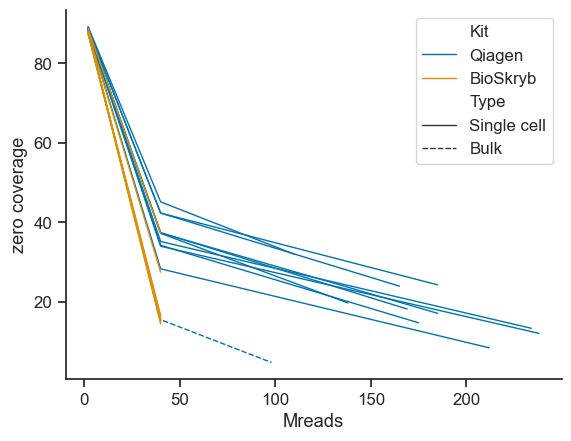

In [5]:
ax = sns.lineplot(
    data=data,
    x="Mreads",
    y="zero coverage",
    hue="Kit",
    style="Type",
    units="NGI ID",
    estimator=None,
    lw=1,
)

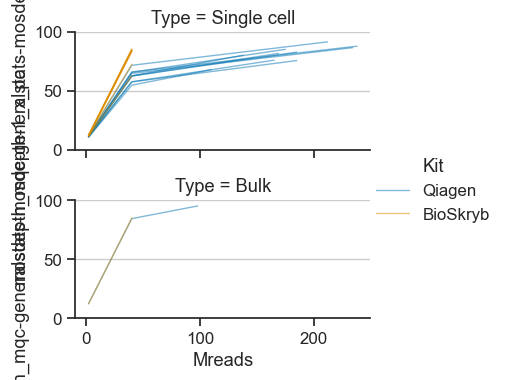

In [6]:
g = sns.relplot(
    kind="line",
    data=data,
    x="Mreads",
    y="mosdepth_mqc-generalstats-mosdepth-1_x_pc",
    hue="Kit",
    row="Type",
    height=2,
    aspect=2,
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.5,
)
g.set(ylim=(0,100))
for ax in g.axes.flat:
    ax.grid(True, axis="y")

In [7]:
d = data.query("Set == '40'")

d.groupby(["Kit", "Type"])["zero coverage"].mean().round(1)

Kit       Type       
BioSkryb  Bulk           14.9
          Single cell    18.9
Qiagen    Bulk           15.5
          Single cell    37.3
Name: zero coverage, dtype: float64

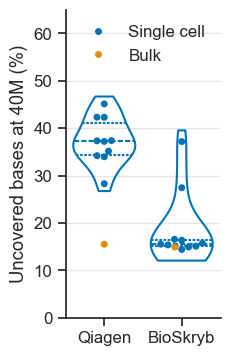

In [8]:
d = data.query("Set == '40'")

fig, ax = plt.subplots(figsize=(2, 4))

ax = sns.violinplot(
    data=d.query('Type == "Single cell"'), 
    x="Kit", 
    y="zero coverage", 
    inner="quart", 
    fill=None, 
    cut=0.5,
    density_norm="width", 
    ax=ax,
    legend=False
)
ax = sns.swarmplot(
    data=d,
    x="Kit",
    y="zero coverage",
    hue="Type",
    ax=ax
)
ax.set_ylabel("Uncovered bases at 40M (%)")
ax.set_ylim(0,65)
plt.legend(frameon=False, framealpha=0)
ax.set_xlabel("")
sns.move_legend(ax, loc="upper right")
ax.grid(True, axis='y', alpha=0.5)
plt.savefig(figdir / "uncovered_bases.svg", bbox_inches="tight")

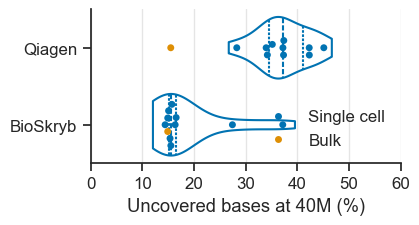

In [9]:
d = data.query("Set == '40'")

fig, ax = plt.subplots(figsize=(4, 2))

ax = sns.violinplot(
    data=d.query('Type == "Single cell"'), 
    y="Kit", 
    x="zero coverage", 
    inner="quart", 
    fill=None, 
    cut=0.5,
    density_norm="width", 
    ax=ax,
    legend=False
)
ax = sns.swarmplot(
    data=d,
    y="Kit",
    x="zero coverage",
    hue="Type",
    ax=ax
)
ax.set_xlabel("Uncovered bases at 40M (%)")
ax.set_xlim(0,60)
plt.legend(frameon=False, framealpha=0)
ax.set_ylabel("")
sns.move_legend(ax, loc="lower right")
ax.grid(True, axis='x', alpha=0.5)
plt.savefig(figdir / "uncovered_bases_h.svg", bbox_inches="tight")

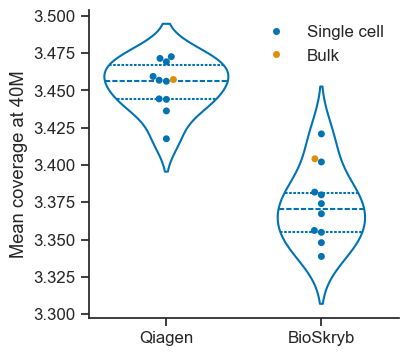

In [10]:
d = data.query("Set == '40'")

fig, ax = plt.subplots(figsize=(4, 4))

ax = sns.violinplot(
    data=d.query('Type == "Single cell"'), 
    x="Kit", 
    y="mosdepth_mqc-generalstats-mosdepth-mean_coverage", 
    inner="quart", 
    fill=None, 
    #color="k", 
    ax=ax,
    legend=False
)
ax = sns.swarmplot(
    data=d,
    x="Kit",
    y="mosdepth_mqc-generalstats-mosdepth-mean_coverage",
    hue="Type",
    ax=ax
)
ax.set_ylabel("Mean coverage at 40M")
#ax.set_ylim(0,60)
plt.legend(frameon=False, framealpha=0)
ax.set_xlabel("")
sns.move_legend(ax, loc="upper right")

#plt.savefig(figdir / "uncovered_bases.svg", bbox_inches="tight")

## Mosdepth coverage

In [11]:
depth = []

basepath = Path("../analysis/downsample_40M/downstream/mosdepth")
for sample in human_samples["NGI ID"]:
    tsv = basepath / f"{sample}.mosdepth.global.dist.txt"
    d = pd.read_csv(tsv, sep="\t", names=["region", "depth", "cumulative"])
    #d = d.query("region == 'total'")
    d["relative_depth"] = d.groupby("region")["cumulative"].transform(
        lambda x: x.rolling(2).apply(lambda x: x.iloc[1]-x.iloc[0]).fillna(0))
    d["cumulative_percentage"] = d["cumulative"] * 100
    d["NGI ID"] = sample
    d = d.merge(samples, on="NGI ID")
    depth.append(d)

depth = pd.concat(depth).reset_index(drop=True)
depth.head()

,region,depth,cumulative,relative_depth,cumulative_percentage,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,chr1,74,0.00008,0.00000,0.008,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,chr1,73,0.00009,0.00001,0.009,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
2,chr1,72,0.00010,0.00001,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
3,chr1,71,0.00010,0.00000,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
4,chr1,70,0.00011,0.00001,0.011,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell


In [12]:
depth

,region,depth,cumulative,relative_depth,cumulative_percentage,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type
0,chr1,74,0.00008,0.00000,0.008,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
1,chr1,73,0.00009,0.00001,0.009,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
2,chr1,72,0.00010,0.00001,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
3,chr1,71,0.00010,0.00000,0.010,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
4,chr1,70,0.00011,0.00001,0.011,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell
...,...,...,...,...,...,...,...,...,...,...,...,...,...
225660,total,4,0.41133,0.10820,41.133,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk
225661,total,3,0.53238,0.12105,53.238,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk
225662,total,2,0.67360,0.14122,67.360,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk
225663,total,1,0.78556,0.11196,78.556,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk


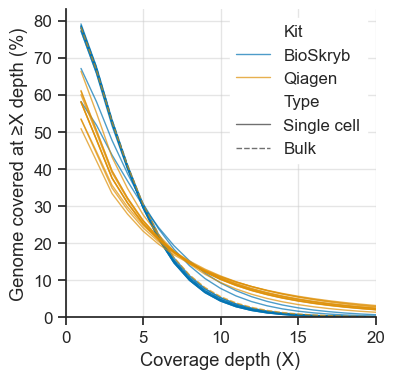

In [13]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.lineplot(
    data=depth.query("depth > 0 & region == 'total'"),
    x="depth",
    y="cumulative_percentage",
    hue="Kit",
    hue_order=reversed(["Qiagen", "BioSkryb"]),
    style="Type",
    style_order=["Single cell", "Bulk"],
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
)
ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.set_ylabel("Genome covered at ≥X depth (%)")
ax.set_xlabel("Coverage depth (X)")
ax.grid(True, axis='both', alpha=0.5)
plt.legend(edgecolor="w", framealpha=1, loc="upper right")

plt.savefig(figdir / "coverage_depth.svg", bbox_inches="tight")

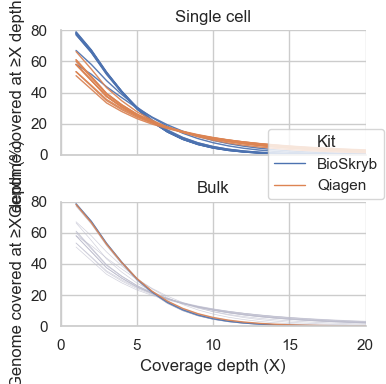

In [14]:
d = depth.query("depth > 0 & region == 'total'").copy()


p = (
    so.Plot(d, x="depth", y="cumulative_percentage", color="Kit", group="NGI ID")
    .facet(
        #col="Kit",
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.9), color="Kit", group="NGI ID")
    .limit(x=(0, 20), y=(0,80))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .layout(size=(4, 4), engine="tight")# extent=[0, 0, 0.8, 1])
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="Coverage depth (X)",
        y="Genome covered at ≥X depth (%)",
    )
    .save(figdir / "coverage_depth_split.svg", dpi=300, bbox_inches="tight", transparent=True)

)
p.show()

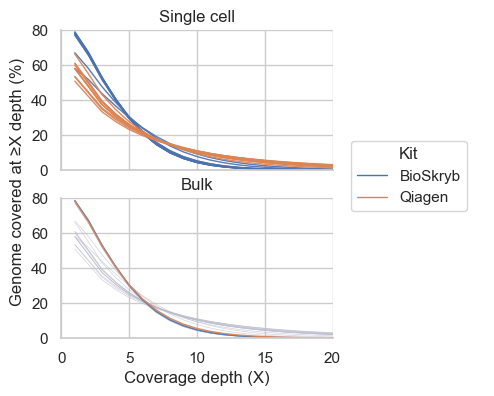

In [ ]:
d = depth.query("depth > 0 & region == 'total'").copy()

fig = plt.figure(figsize=(3.5,4))
fig.text(0, 0.5, "Genome covered at ≥X depth (%)", ha="center", va="center", 
         rotation=90, fontsize=12)

p = (
    so.Plot(d, x="depth", y="cumulative_percentage", color="Kit", group="NGI ID")
    .facet(
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.9), color="Kit", group="NGI ID")
    .limit(x=(0, 20), y=(0,80))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="Coverage depth (X)",
        y="",
    )
    .on(fig)
    .save(figdir / "coverage_depth_split_narrow.svg", dpi=300, bbox_inches="tight", transparent=True)

)

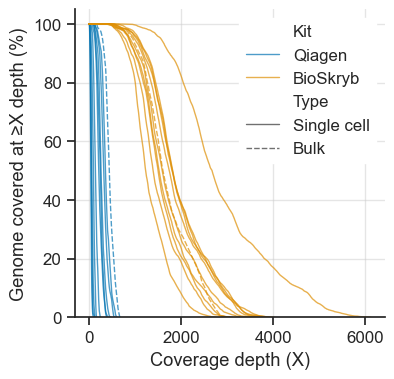

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))

ax = sns.lineplot(
    data=depth.query("depth > 0 and region == 'chrM'"),
    x="depth",
    y="cumulative_percentage",
    hue="Kit",
    hue_order=["Qiagen", "BioSkryb"],
    style="Type",
    style_order=["Single cell", "Bulk"],
    units="NGI ID",
    estimator=None,
    lw=1,
    alpha=0.7,
)
#ax.set_xlim(0, 20)
ax.set_ylim(bottom=0)
ax.set_ylabel("Genome covered at ≥X depth (%)")
ax.set_xlabel("Coverage depth (X)")
ax.grid(True, axis='both', alpha=0.5)
plt.legend(edgecolor="w", framealpha=1, loc="upper right")
#plt.savefig(figdir / "coverage_depth.svg", bbox_inches="tight")

## Preseq GC extrap

In [29]:
datagc = []
# Command: less /sw/data/igenomes/Homo_sapiens/NCBI/GRCh38/Sequence/WholeGenomeFasta/genome.fa.fai | awk '{sum += $2} END {print sum}'
# genome_territory = 3099922541

# Picard NonNFastaSize
genome_territory = 2934876545

basepath = Path("../analysis/downsample_40M/downstream/preseq")
for sample in human_samples["NGI ID"]:
    tsv = basepath / f"{sample}.gc_extrap.txt"
    d = pd.read_csv(tsv, sep="\t")
    # d = pd.concat([
    #     pd.DataFrame({
    #         "TOTAL_BASES": [0],
    #         "EXPECTED_COVERED_BASES": [0],
    #         "LOWER_95%CI": [0],
    #         "UPPER_95%CI": [0]
    #     }),
    #     d, 
    # ])
    d["NGI ID"] = sample
    d = d.merge(samples, on="NGI ID")
    datagc.append(d)

datagc = pd.concat(datagc).reset_index(drop=True)
datagc["Genome coverage"] = datagc["EXPECTED_COVERED_BASES"] / genome_territory * 100
datagc["Genome coverage Lower"] = datagc["LOWER_95%CI"] / genome_territory * 100
datagc["Genome coverage Upper"] = datagc["UPPER_95%CI"] / genome_territory * 100

datagc["Gb"] = datagc["TOTAL_BASES"] / 1e9
datagc["Mreads"] = datagc["TOTAL_BASES"] / (300 * 1e6) # 2x150 reads
#datagc = datagc[datagc["LOWER_95%CI"] > 0]
datagc

,TOTAL_BASES,EXPECTED_COVERED_BASES,LOWER_95%CI,UPPER_95%CI,NGI ID,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Genome coverage,Genome coverage Lower,Genome coverage Upper,Gb,Mreads
0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,0.000000,0.000000,0.000000,0.0,0.000000
1,1.000000e+09,6.948062e+08,6.947556e+08,6.948475e+08,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,23.674119,23.672394,23.675529,1.0,3.333333
2,2.000000e+09,1.082572e+09,1.082498e+09,1.082639e+09,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,36.886458,36.883950,36.888757,2.0,6.666667
3,3.000000e+09,1.337362e+09,1.337261e+09,1.337443e+09,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,45.567909,45.564479,45.570663,3.0,10.000000
4,4.000000e+09,1.519899e+09,1.519744e+09,1.519994e+09,P33410_1001,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,51.787494,51.782220,51.790734,4.0,13.333333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2195,9.500000e+10,2.882181e+09,2.825944e+09,3.191490e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.204509,96.288339,108.743570,95.0,316.666667
2196,9.600000e+10,2.882542e+09,2.825970e+09,3.193967e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.216823,96.289233,108.827998,96.0,320.000000
2197,9.700000e+10,2.882898e+09,2.825995e+09,3.196414e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.228943,96.290096,108.911345,97.0,323.333333
2198,9.800000e+10,2.883248e+09,2.826020e+09,3.198828e+09,P33410_1024,B_H3_10_cells,False,BioSkryb,MM1S cell line,Human,BioSkryb (Bulk),Bulk,98.240874,96.290928,108.993631,98.0,326.666667


In [17]:
bases = []

paths = {
    "2": Path("../analysis/downsample_qc/downstream_qc"),
    "40": Path("../analysis/downsample_40M/downstream"),
    "100+": Path("../analysis/qiagen_repli_g_full/downstream")
}

for sample in human_samples["NGI ID"]:
    for s, path in paths.items():
        log = path / "preseq" /  f"{sample}.gc_extrap.txt.log"
        if not log.exists():
            print(log)
            continue
    
        n_bases = 0
        n_covered = 0 
        with open(log) as f:
            for line in f:
                if line.startswith("TOTAL BASES"):
                    n_bases = float(line.strip().split("=")[1])
                
                if line.startswith("TOTAL COVERED BASES"):
                    n_covered = float(line.strip().split("=")[1])

        bases.append({"NGI ID": sample, "TOTAL_BASES": n_bases, "EXPECTED_COVERED_BASES": n_covered, "Set": s})

bases = pd.DataFrame(bases)
bases = bases.merge(samples, on="NGI ID")
bases["Genome coverage"] = bases["EXPECTED_COVERED_BASES"] / genome_territory * 100
bases["Gb"] = bases["TOTAL_BASES"] / 1e9
bases["Mreads"] = bases["TOTAL_BASES"] / (300 * 1e6) # 2x150
bases.head()


../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1013.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1014.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1015.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1016.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1017.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1018.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1019.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1020.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1021.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1022.gc_extrap.txt.log
../analysis/qiagen_repli_g_full/downstream/preseq/P33410_1024.gc_extrap.txt.log


,NGI ID,TOTAL_BASES,EXPECTED_COVERED_BASES,Set,User ID,IsSingleCell,Kit,Sample,Genome,SampleName,Type,Genome coverage,Gb,Mreads
0,P33410_1001,5.408960e+08,3.315120e+08,2,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,11.295603,0.540896,1.802987
1,P33410_1001,2.876870e+09,1.310670e+09,40,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,44.658437,2.876870,9.589567
2,P33410_1001,6.435600e+10,2.588600e+09,100+,Q_B2_cell_01,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#01),Single cell,88.201325,64.356000,214.520000
3,P33410_1002,5.411660e+08,3.267040e+08,2,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,11.131780,0.541166,1.803887
4,P33410_1002,2.907980e+09,1.256590e+09,40,Q_C2_cell_02,True,Qiagen,MM1S cell line,Human,Qiagen (Cell#02),Single cell,42.815770,2.907980,9.693267


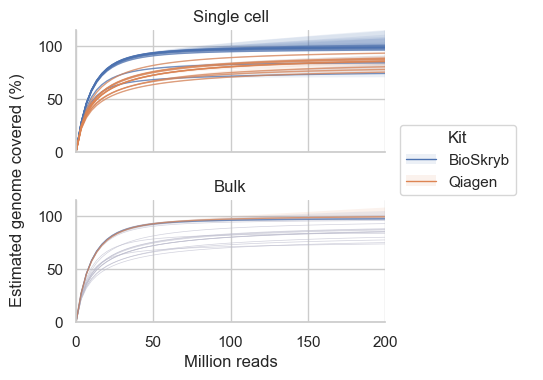

In [ ]:
d = datagc.copy()

fig = plt.figure(figsize=(4,4))
fig.text(0, 0.5, "Estimated genome covered (%)", ha="center", va="center", rotation=90, fontsize=12)
p = (
    so.Plot(d, x="Mreads", y="Genome coverage", color="Kit", group="NGI ID",
            ymin="Genome coverage Lower", ymax="Genome coverage Upper",)
    .facet(
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.7), color="Kit", group="NGI ID")
    .add(so.Band(alpha=0.1))
    .limit(y=(0,115), x=(0, 200))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .layout(engine="tight")# extent=[0, 0, 0.8, 1])
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="Million reads",
        y="",
    )
    .on(fig)
    .save(figdir / "gc_extrap_genome_coverage_40M.svg", dpi=300, bbox_inches="tight", transparent=True)
)


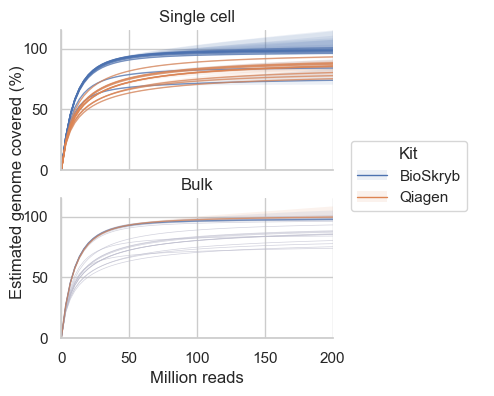

In [30]:
d = datagc.copy()

fig = plt.figure(figsize=(3.5,4))
fig.text(0, 0.5, "Estimated genome covered (%)", ha="center", va="center", 
         rotation=90, fontsize=12)
p = (
    so.Plot(d, x="Mreads", y="Genome coverage", color="Kit", group="NGI ID",
            ymin="Genome coverage Lower", ymax="Genome coverage Upper",)
    .facet(
        row="Type",
    )
    .add(so.Lines(color="#bbca", linewidth=0.5), col=None, row=None, group="NGI ID")
    .add(so.Lines(linewidth=1, alpha=0.7), color="Kit", group="NGI ID")
    .add(so.Band(alpha=0.1))
    .limit(y=(0,115), x=(0, 200))
    .scale(
        color=so.Nominal(order=["BioSkryb", "Qiagen"]),
    )
    .theme(sns.axes_style("whitegrid") | sns.plotting_context("notebook"))
    .theme(custom_params)
    .label(
        x="Million reads",
        y="",
    )
    .on(fig)
    .save(figdir / "gc_extrap_genome_coverage_40M_narrow.svg", dpi=300, bbox_inches="tight", transparent=True)
)